# Chapter-02. 文本静态词向量表示

## 【章节目标】
- 掌握使用词袋模型(BOW)进行文本表示
- 掌握使用word2vec进行文本表示
- 掌握使用fasttext进行文本表示
- 掌握使用glove进行文本表示
- 理解以上方法与词袋模型的不同点

## 【章节内容】
### 2.1 文本静态词向量表示概述
#### 2.1.1 文本表示的基本概念
**定义**

- 所谓文本表示即通过某种形式将文本字符串表示成计算机所能处理的数值向量。

**文本表示必要性**

- 计算机不能直接对文本字符串进行处理，需要进行数值化或者向量化；
- 不仅传统的机器学习算法需要这个过程，深度学习也需要这个过程；
- 同时，良好的文本表示形式也可以极大的提升算法效果。

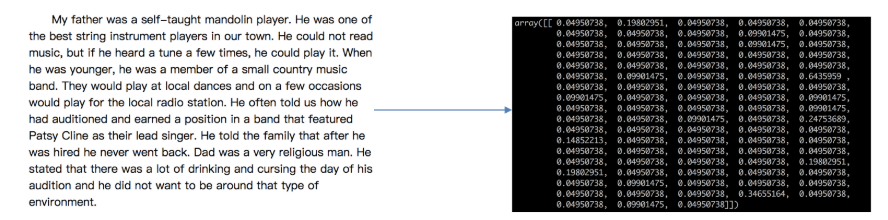  
图中，将一大段文本转换成的计算机可以识别的数组向量

#### 2.1.2 文本表示的方法
文本表示一直以来都是自然语言处理研究领域中的一个热点问题，总体来讲主要分为二大类：

- 基于One-hot Representation(独热编码) 的Bag of Words模型。

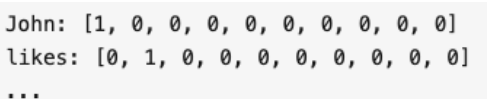

- 基于Distributional Representation(分布式表示)的词向量模型。

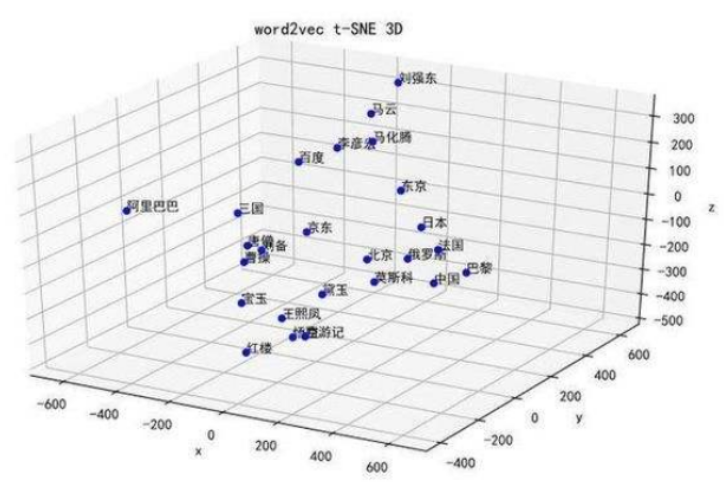

#### 2.1.3 One-hot Representation简介
**基本思想**

- one-hot即独立热词，词语被表示成一个维度为词表大小的向量，这个向量中只有一个维度是1其他位置都是0。
- 假如词表中只有四个个词“奥巴马”、“特朗普”、“宣誓”、“就职”，那么他们将被表示为：  
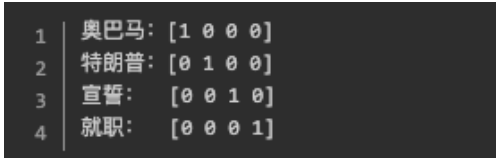

**one-hot表示的优点**

- 简单易用

**one-hot表示的缺点**

- 浪费存储资源
    - 如果一个词表有十万个单词，那么就需要十万维的向量来表示每一个单词，而每个向量只有一位是1，在储存上造成大量浪费，在深度学习场景中容易受到维度灾难的困扰。
- 丢失相关语义信息
    - 奥巴马和特朗普都是美国总统，而one-hot表示出的两个向量是正交向量，也就是他们之间毫无关系，这显然是丢失了相关语义信息。因此我们需要更好的表示方法。
- 改进措施
    - 采用分布式表示方法

#### 2.1.4 Distributional Representation简介
**基本思想**

- 分布式表示方法的理论基础就是上下文相似的词，其语义也相似。
- 这和我们的认知是一致的，当我们在阅读文章时发现不认识的字，也会通过上下文来猜测字的含义。比如：

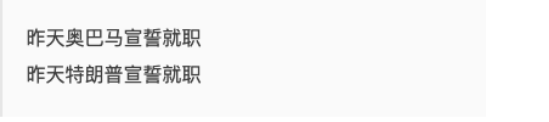

- 如果两个词可以互换，那么它们的语义就是相似的，所以奥巴马和特朗普应该具有相似的语义。
- 分布式表示方法要做的就是利用上下文信息把每一个词映射成一个维度固定的短向量，这样在它们所构成的向量空间中，每个词都是一个点，就可以通过距离来判断语义的相似度。

**举例**

例如，在如下图的分布式向量中，“奥巴马”和“特朗普”在向量空间中的距离很近，因此可以判断这两个词的语义非常相似。

- 奥巴马
- 特朗普

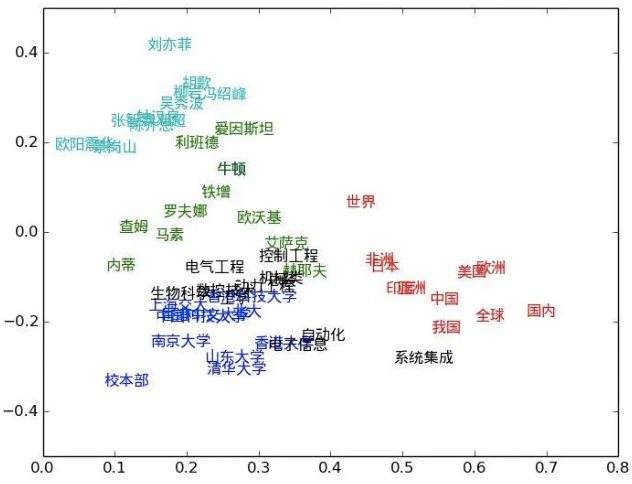

**方法归类**

根据建模方式的不同，将分布式算法归纳为两大类：

- 基于神经网络的分布式式表示
    - 代表模型：word2vec，fasttext
- 基于共现矩阵的分布式表示
    - 代表模型：glove

### 2.2 词袋模型
#### 2.2.1 单词的表示（one-hot）
one hot在特征提取上属于词袋模型(bag of words)

**举例**

- 假设我们的语料库中有三段话
> 1.我们今天去爬山  
> 2.你们昨天跑步  
> 3.你们又去爬山又去跑步  

- 将语料库中所有的词拉成一个向量，给每个词一个下标，就得到对应的词典：
> {“我们”:1，”又”:2，”去”:3，”爬山”:4，”今天”:5，”你们”:6，”昨天”:7，”跑步”:8}

- 那么单词的one-hot表示如下:
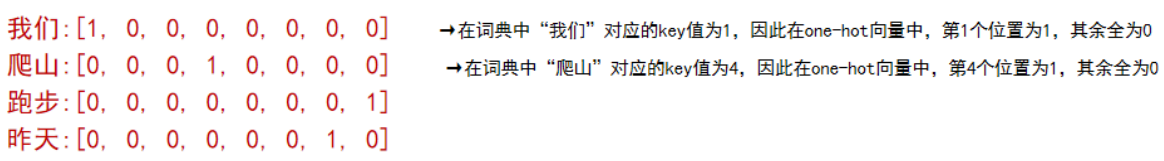

#### 2.2.2 句子的表示(Bag of Words)
**基本思想**

**Bag of words(BOW)** 的基本思想就是将每篇文档都看成一个袋子（因为里面装的都是词汇，所以称为词袋，Bag of words即因此而来），忽略其词序和语法、句法，仅仅将其看做是一些词汇的集合，文本中的每个词汇都是独立的。

常见的BOW模型

- Boolean布尔向量
- Count词频向量

**boolean布尔向量**

向量为词典的大小，每个句子对应词典中单词出现与否的情况，出现为1，不出现为0。

**举例**

- 对于语料库：
> 1.我们今天去爬山  
> 2.你们昨天跑步  
> 3.你们又去爬山又去跑步 

- 构建词典：  
> {“我们”:1，”又”:2，”去”:3，”爬山”:4，”今天”:5，”你们”:6，”昨天”:7，”跑步”:8}

- 那么单词的boolean布尔向量表示如下：  
> 我们/今天/去/爬山:[1,0,1,1,1,0,0,0] --- 句子中出现了：我们、今天、去、爬山 这四个词  
> 你们/昨天/跑步:[0,0,0,0,0,1,1,1] --- 句子中出现了：你们、昨天、跑步 这三个词  
> 你们/又/去/爬山/又/去/跑步:[0,1,1,1,0,1,0,1] --- 句子中出现了：你们、又、去、爬山、跑步 这5个词。虽然“又”和“去”出现了两次，但是我们不关心次数，只关心是否出现

**count词频向量**

- 向量为词典的大小，每个句子对应词典中单词出现的次数（本质意义是将整个句子中的每个词向量加和得到）。
- 其中，每个句子对应词典中单词出现的次数称为词频TF（term frequency），TF越大一般来说越重要。

**举例**

- 对于语料库：
> 1.我们今天去爬山  
> 2.你们昨天跑步  
> 3.你们又去爬山又去跑步 

- 构建词典：  
> {“我们”:1，”又”:2，”去”:3，”爬山”:4，”今天”:5，”你们”:6，”昨天”:7，”跑步”:8}

- 那么单词的boolean布尔向量表示如下： 
> 我们/今天/去/爬山:[1,0,1,1,1,0,0,0] 句子中出现了：我们、今天、去、爬山 这四个词各出现了1次  
> 你们/昨天/跑步:[0,0,0,0,0,1,1,1] 句子中出现了：你们、昨天、跑步 这三个词各出现了1次  
> 你们/又/去/爬山/又/去/跑步:[0,2,2,1,0,1,0,1] 句子中出现了：你们、又、去、爬山、跑步 这5个词。其中“又”和“去”出现了2次

**count词频向量的缺陷**

- 用词频（TF）来表示一个词在文本中的重要性有一个致命的缺点：常用词的重要性会被放大。
- 在一段文本中可能常用词，例如“我们”会多次出现，但是它对文本的重要性其实并没有那么大，当然大多数情况下出现得多的词重要性也会相对较强，所以不能一概而论。  
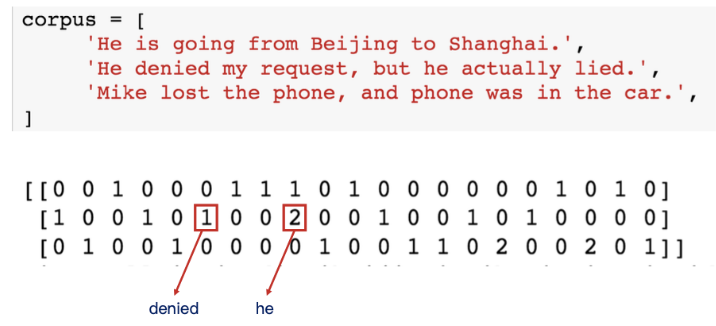  
图中，he的tf值为2，denied的tf值为1，按照count词频向量的逻辑，he最重要，但事实是he并不重要。

#### 2.2.3 文本表示（TF-IDF）
为了克服count词向量存在的缺陷，提出了TF-IDF算法。

**基本思想**

- TF-IDF 的思想是一个单词在其所在文本中出现的次数越多，在其他文本中出现的次数越少，那么这个单词就能很好的表征单词所在的文本。

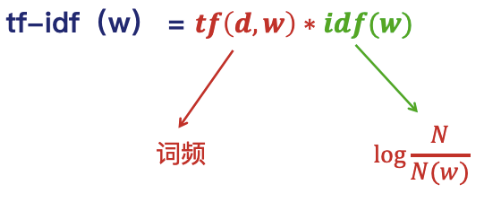

**TF-IDF中的几个术语**

- TF（term frequency）：词频，某个词在文档中出现的次数，TF 越大一般来说越重要
- DF（document frequency）：文档频率，某个词在所有文档中出现的文档数，DF 越大表示这个词越有可能是常用词，自然也越不重要
- IDF（inverse document frequency）：逆文档频率，它是 DF 的倒数，IDF 越大表示该词越少见，也越重要
- TF-IDF ：TF IDF，综合了 TF 和 IDF 两个因素来平衡词的重要性

**TF-IDF向量的计算实例**

- 语料库：  
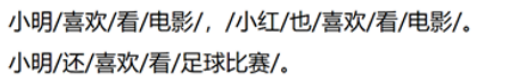

- Step1：计算每个分词的词频，考虑到文章有长短之分，为了便于不同文章的比较，进行"词频"标准化。  
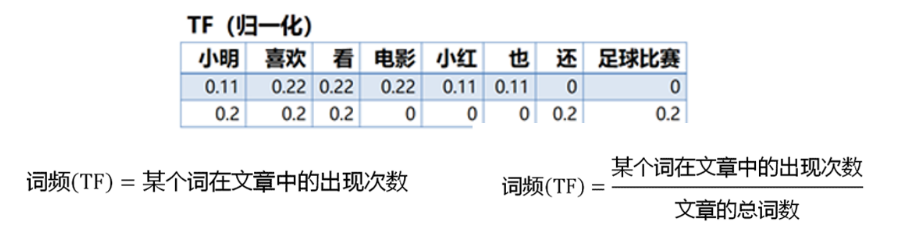

- Step2：计算每个分词的IDF值。  
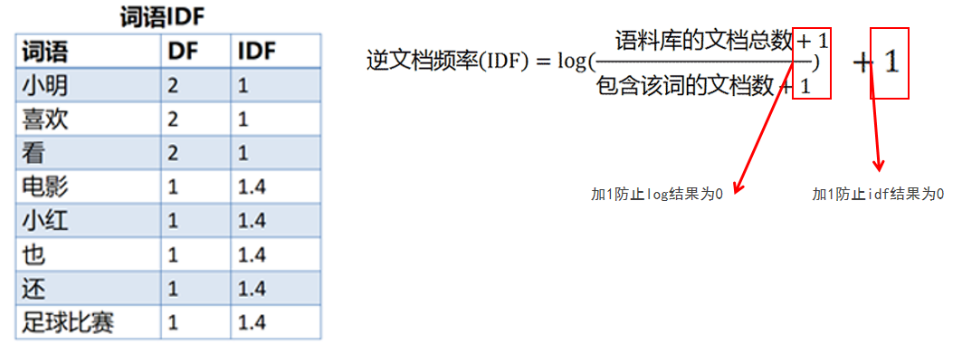

- Step3：将TF和IDF结合，得到TF-IDF值。
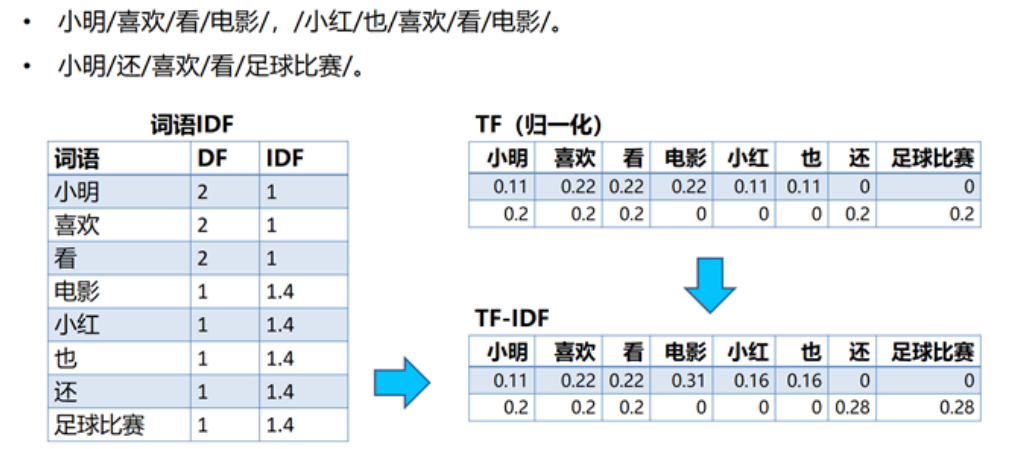  
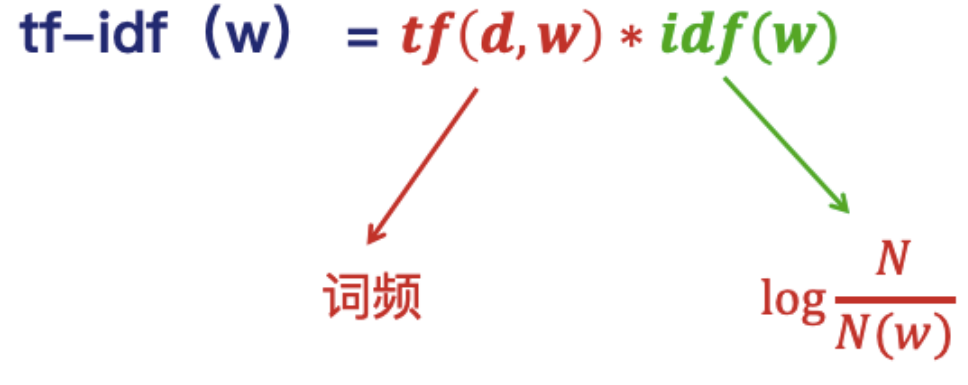

#### 2.2.4 词袋模型（Bag of Words）的缺点
**词袋模型的三个缺点**

- 由于词典数量较多，而单一文本中出现的词并不会太多，所以用词袋模型表示的特征向量是非常稀疏的。
- 这种表示方法无法表达单词与单词之间的相似程度，如“漂亮”和“美丽”可以表达相似的意思，但是one-hot法无法将之表示出来。
- 它忽略了文本的语法和不同词之间的顺序，仅仅将其看成是若干个词汇的集合，每个词的出现都是独立的。不同词语的重要性仅仅是根据出现的次数来表示，但真实的语言中可能并不是如此。

**解决词典模型缺点的方法**

- 对于相似度问题和稀疏问题，可以采用分布式表示来解决。
- 对于词的顺序问题，可以采用N-gram或者分布式表示。

**分布式解决相似度和稀疏问题**

- 把每一个词映射成一个维度固定的短向量，这样在它们所构成的向量空间中，每个词都是一个点，就可以通过距离来判断语义的相似度。
- 图中，具有相似语义的词向量都分布在相近的位置，例如刘亦菲、胡歌这类人名聚集在一起，山东大学、清华大学这类学校聚集在一起。

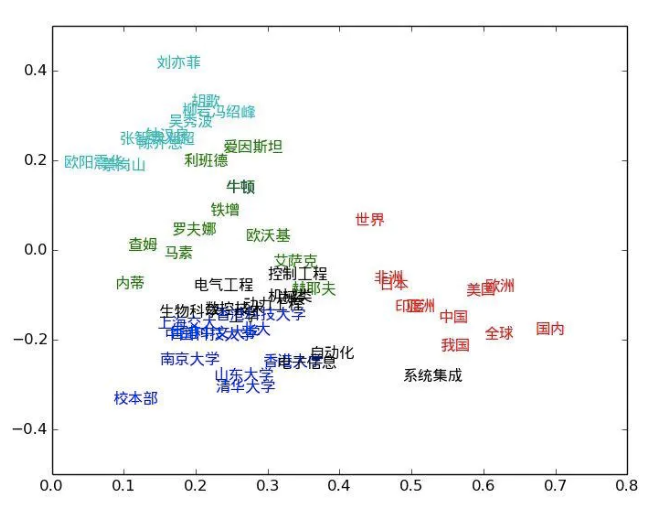


**N-gram解决词顺序的问题**

- 与词袋模型原理类似，Bi-gram将相邻两个单词编上索引，N-gram将相邻N个单词编上索引。

**举例**

- 对于语料库：
> 1.我们今天去爬山  
> 2.你们昨天跑步  
> 3.你们又去爬山又去跑步 

- 构建Bi-gram词典：  
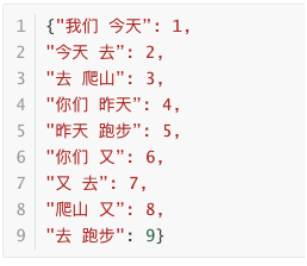

- 文本表示如下：
> 你们又去爬山又去跑步：[0,0,1,0,0,1,2,1,1]  
> - →在词典中“我们 今天”对应的key值为1，而“你们又去爬山又去跑步”中没有“我们 今天”，因此在n-gram向量中，第1个位置为0。
> - →在词典中“你们 又”对应的key值为6，而“你们又去爬山又去跑步”中出现了1次“你们 又”，因此在n-gram向量中，第6个位置为1。
> - →同理，在词典中“又 去”对应的key值为7，而“你们又去爬山又去跑步”中出现了2次“又 去”，因此在n-gram向量中，第7个位置为2。

### 2.3 基于神经网络的分布式表示-word2vec
#### 2.3.1 word2vec介绍
**基本思想**

- Word2vec是词的一种表示，他将词以固定维数的向量表示出来。

**举例**

- 例如  
> “我爱中国”

- 通过分词分为
> 我/ 爱 / 中国。

- 那么这个时候这三个词都将表示为n维的词向量（n的大小可以自定义）  
> 中国=[x1,x2,.....,xn]

- 另外一个很经典的案例 ,将词语表示为一个二维的向量，可以得到如下的结果。  
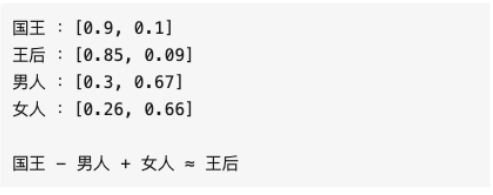

#### 2.3.2 word2vec优点
**Word2vec的优点**

- 传统的基于词袋模型 one-hot representation在判定同义词，相似句子的时候很无力。
    - 例如在一个只有两个词的词典中。“快递”被编码为v1 = [0,1]，“快件”被编码为v2 =[1,0]，计算两个的相似度=v1*v2 = 0
- 而word2vec充分利用上下文信息，对上下文进行训练。每个词不再是只有一个位置为1，其余位置为0的稀疏向量。而是一个稠密的固定维度向量。
    - 直观上可减少额外存储和计算开销。
    - 其次，在深层次的语义理解上，经过训练后的词向量能利用上下文信息。能判定找出相似词语。
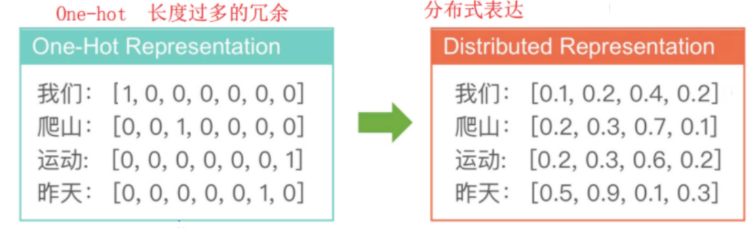

**举例：如何用 Word2vec 寻找相似词？**

看下面两句话：
> - 『她们 夸 吴彦祖 帅 到 没朋友』
> - 『她们 夸 我 帅 到 没朋友』

可以看出：“我”(x)和“吴彦祖”(x)的上下文语境(y)是一样的。从而有 f(吴彦祖) = f(我) = y，所以大数据告诉我们：我 = 吴彦祖（完美的结论）

#### 2.3.3 word2vec先导知识
**理解word2vec的前提**

- sigmoid函数
- softmax函数
- Huffman树
- 语言模型
- 神经网络语言模型（NNLM）

**Sigmoid是什么?**

- sigmoid函数，用于隐层神经元输出，取值范围为(0,1)，它可以将一个实数映射到(0,1)的区间，可以用来做二分类。

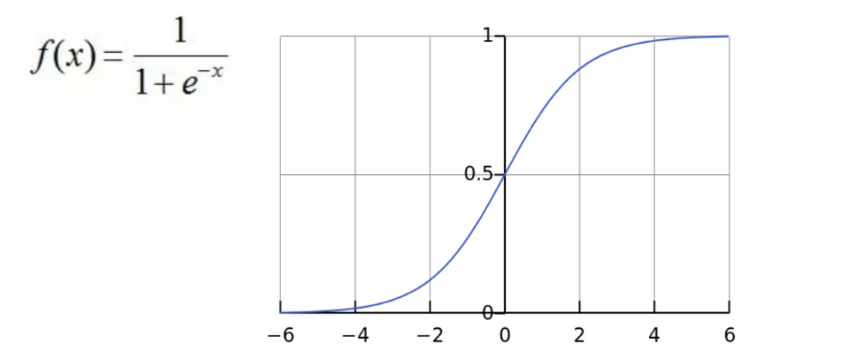

**Sigmoid函数的基本性质**

- 定义域:(−∞,+∞)
- 值域:(−1,1)
- 函数在定义域内为连续和光滑函数 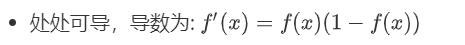  
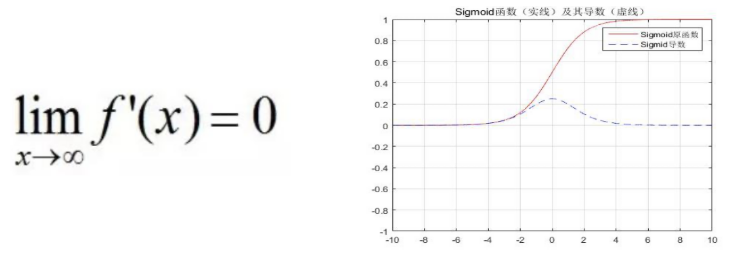

**Softmax**

Softmax要解决这样一个问题: 我有一个向量，想用数学方法把向量中的所有元素归一化为一个概率分布。也就是说，该向量中的元素在[0,1]范围内，且所有元素的和为1。  
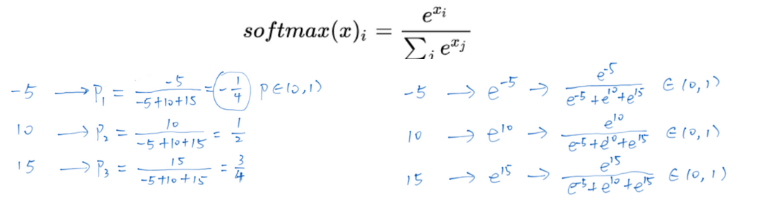

**认识Huffman树**

- 树的带权路径长度：规定为所有叶子结点的带权路径长度之和。
- Huffman树：给定n个权值作为n个叶子结点，构造一棵二叉树，若它 的带权路径长度达到最小，则称这样的二叉树为最优二叉树，也称为 Huffman树。  
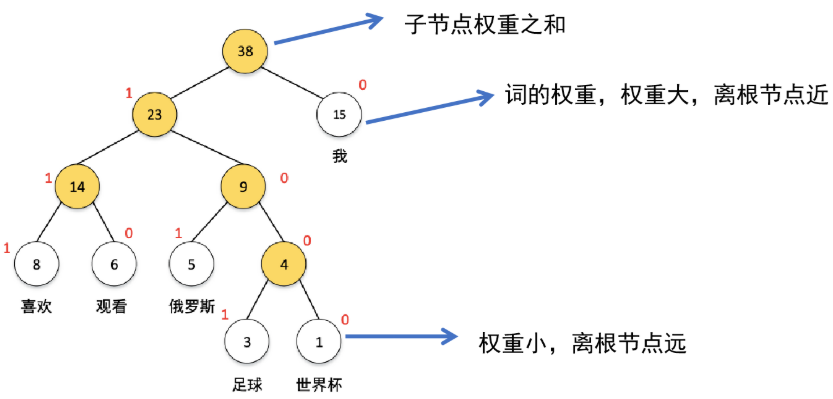

**Huffman树构造算法**

- Huffman树构造：给定n个权值w1, w2, ......, wn作为二叉树的n个叶子 结点，可通过以下算法来构造一棵Huffman树。
- Huffman树构造算法

- Huffman树构造算法
    - (1)将w1, w2, ......, wn看成是有n棵树的森林(每棵树仅有一个结点)。
    - (2)在森林中选出两个根结点的权值最小的树合并，作为一棵新树的根结点，权值为其左、右子树根结点权值之和。
    - (3)从森林中删除选取的两棵树，并将新树加入森林。
    - (4)重复(2)、(3)步，直到森林中只剩一棵树为止，该树即为所求 的Huffman树。

**Huffman树构造举例**

假设从新浪微博中抓取了若干条与足球相关的微博，经统计，“我”、“喜欢”、“观看”、“俄罗斯”、 “足球”、“世界杯”这六个词出现的次数分别为15，8，6，5，3， 1。请以这6个词为叶子结点，以相应词频当权值，构造一棵Huffman树。  
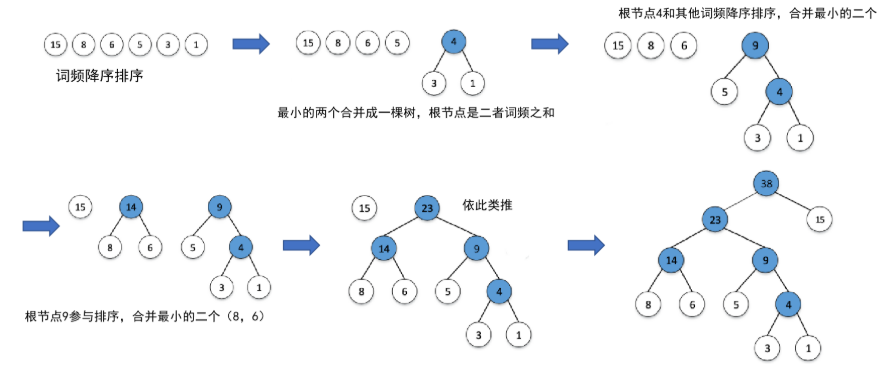

**Huffman树在word2vec中的应用**

- Huffman编码的思想：常用词编码短(笔画少/字母少)，生僻词编码长(笔画多/字母多)。中文中，经常使用的汉字笔画少（大，小，个，如），生僻字一般笔画较多，英语中也有类似现象。
- word2vec中如何用Huffman编码：它把训练语料中的词当成叶子结点，其在语料中出现的次数当作权值，通过构造相应的Huffman树来对每一个词进 行Huffman编码。  
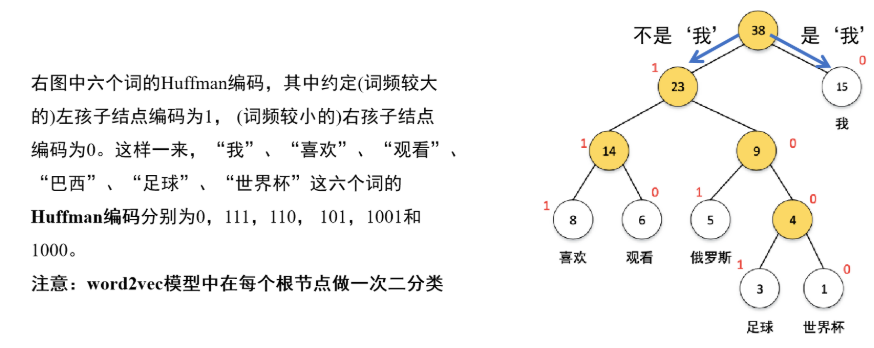

**什么是语言模型?**

- 简单地说，语言模型就是用来计算一个句子的概率的模型，也就是判断一句话是否是人话的概率。
- 比如下面三句话:
> - a：今天天气很好，我们去圆明园约会吧。
> - b：今天很好天气，我们去圆明园约会吧。
> - c：今天我们天气，很好去圆明园约会吧。
- P（a）=? P(b)=? P(c)=? Which is max?

**语言模型概念**

- 语言模型：如何计算一个句子出现的概率呢?
- 我们可以把有史以来人类说过的话都统计一遍，这样就能很方便的计算概率了。然而，你我都知道这条路走不通。
- 假设想知道S在文本中出现的可能性，也就是数学上所说的S的概率， 既然S = w1, w2, ......, wn , 那么不妨把S展开表示：  
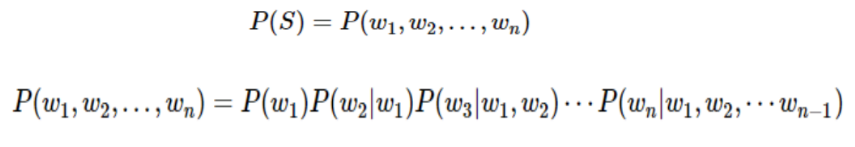  
注意：计算$P(w_1)$很容易，$P(w_2|w_1)$也还能算出来，$P(w_3|w_1,w_2)$已经非常难以计算了。

**语言模型：句子概率计算举例**

- 假设语料库中有1000个词，下面我们考虑计算下面句子出现的概率：  
> 今天/天气/很好，我们/去/圆明园/约会/吧
- 统计P(w1): 有1000个，p(今天)是其中一个
- 统计一阶条件概率P(w2∣w1): 有1000*1000个，p(天气|今天)是其中一个
- 统计二阶条件概率P(w3∣w1,w2): 有1000*1000*1000个，p(很好|今天，天气)是其中一个
- ....
- 依次类推，我们发现两个问题：
    - 1.需要统计的概率太多
    - 2.会有很多组合根本没有出现，无法计算概率
- 为了解决这两个问题，简化计算，我们需要马尔可夫假设。

**语言模型:马尔科夫假设**

- 随意一个词出现的概率只与它前面出现的有限的一个或者几个词有关。
- 假设一个词wi出现的概率只与它前面的wi−1有关，这种假设称为1阶马尔科夫假设。现在，S的概率就变得简单了:  
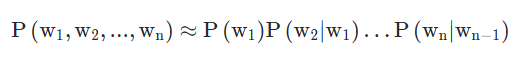
- 接下来的问题就变成了估计条件概率P(wi∣wi−1)  
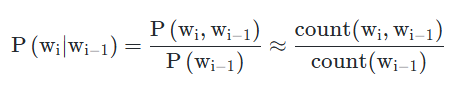

**n-gram语言模型**

- 如果一个词出现的概率与它周围的词无关，我们称之为一元语言模型/unigram:  
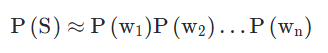

- 如果一个词出现的概率只依赖于它前面的一个词，称之为二元语言模型/bigram:  
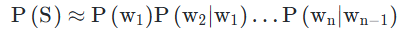

- 如果一个词出现的概率只依赖于它前面的两个词，称之为三元语言模型/trigram：  
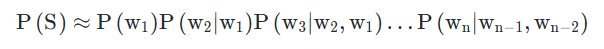

**n-gram语言模型缺点**

- n-gram模型没有考虑上下文中更多的词提供的信息。
- n-gram模型没有考虑词与词之间的相似性。

**举例**

- 如果在一个语料库中，“我爱青岛”出现了6000次，而“我爱大连"只出现了15次，n-gram模型得出的结果是前面一个句子的可能性会比后面一个句子 大得多。但是实际上，这两个句子是相似的，他们在真实的情况下出现的概率也应该是相仿的。
- 神经网络语言模型（NNLM）可以解决N-gram的问题

**神经网络语言模型（NNLM）基本思想**

神经网络语言模型可以概括为以下三点：

- 假定词表中的每一个word都对应着一个连续的特征向量；
- 假定一个连续平滑的概率模型，输入一段词向量的序列，可以输出这段序列的联合概率；
- 同时学习词向量和概率模型的参数 。
    - 值得注意的一点是，这里的词向量也是要学习的参数。
    - 词向量表示词的不同特征：每一个词都是向量空间内的一个点。
    
**神经网络语言模型（NNLM）图解**
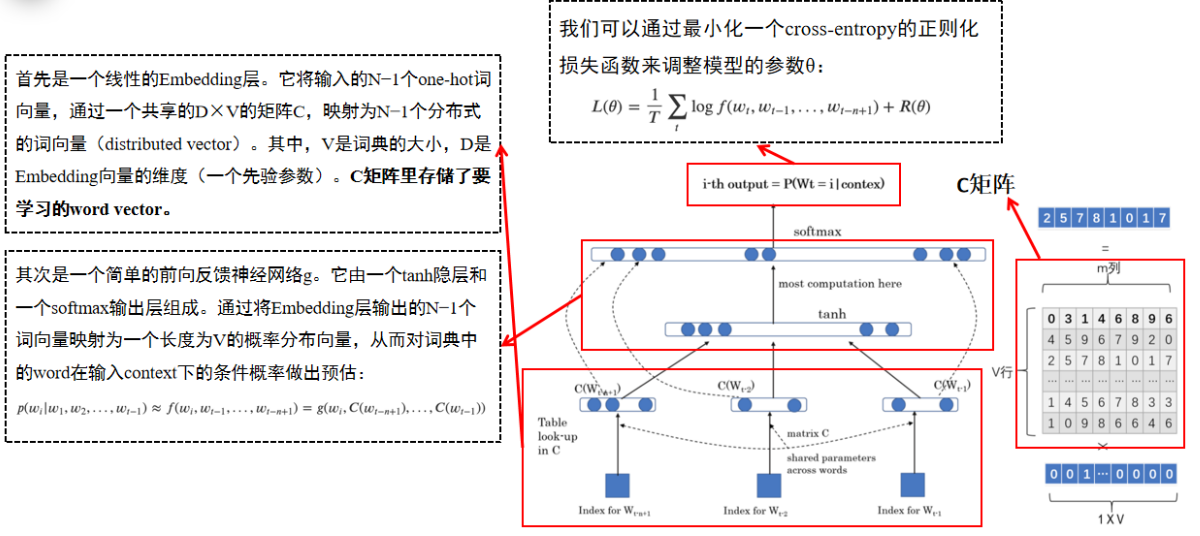

#### 2.3.4 word2vec的两个模型
- CBoW模型：两侧的词(x)预测中间词(y)  
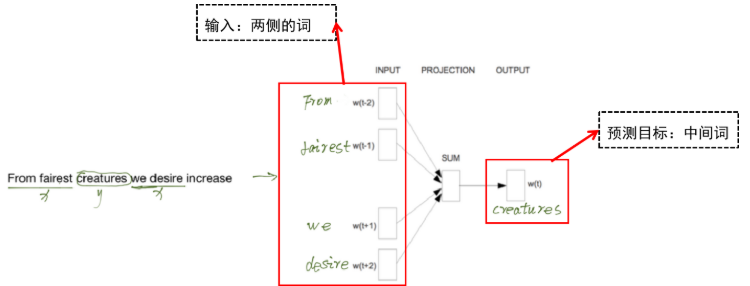
- Skip-gram模型：中间词(x)预测两侧的词(y)  
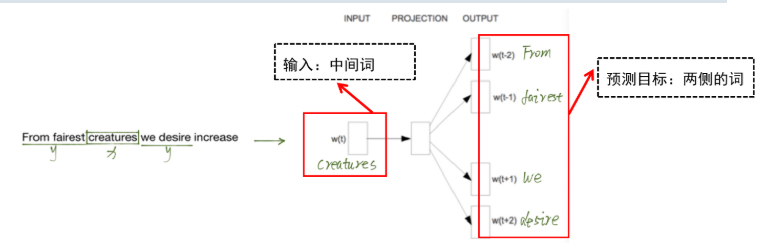

#### ***2.3.5 CBoW模型
我们对原始的NNLM模型做如下改造：

- 移除前向反馈神经网络中非线性的hidden layer，直接将中间层的Embedding layer与输出层的softmax layer连接；
- 忽略上下文环境的序列信息：输入的所有词向量均汇总到同一个Embedding layer；
- 将Future words纳入上下文环境。 得到的模型称之为CBoW模型（Continuous Bag-of-Words Model），也是word2vec算法的第一个模型。

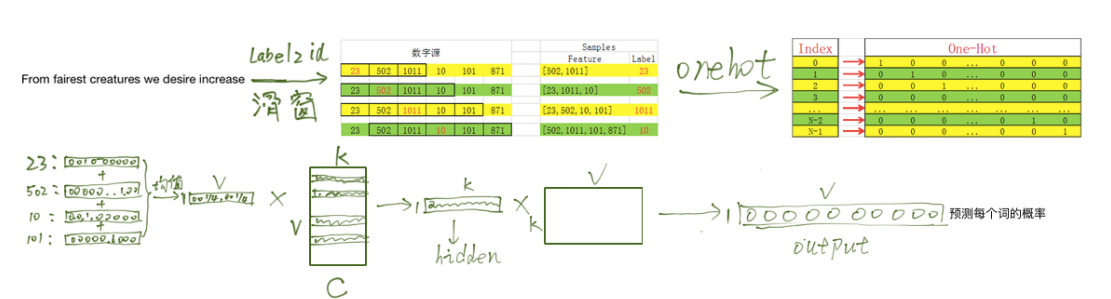  
CBOW模型搭建流程概览

**step1：生成训练样本--滑窗**

文字源中的一句From fairest creatures we desire increase， 即数字源中的23 502 1011 10 101 871；设置“滑窗”（假设窗口长度为2），制作Samples如下图所示：  
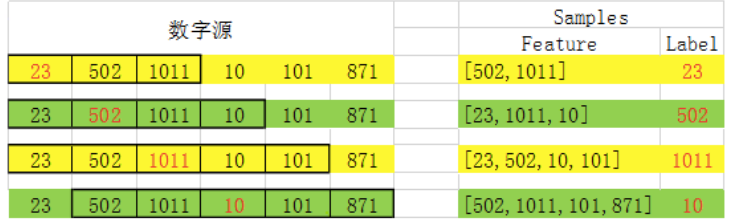  
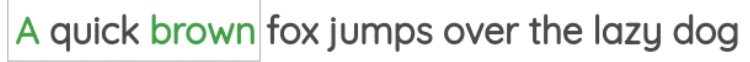  
左右两侧各拿2个词作为x，中间词作为y。左边没有或者右边没有则不取

**step2：生成Onehot编码**

举一个例子，我们有以下文本

- I drink coffee everyday
- 假设我们输入为 I, drink, everyday，那么我们训练的神经网络要使 coffee 的输出概率最大。首先，我们将原来的文本的单词用One-hot编码表示，如下图所示  
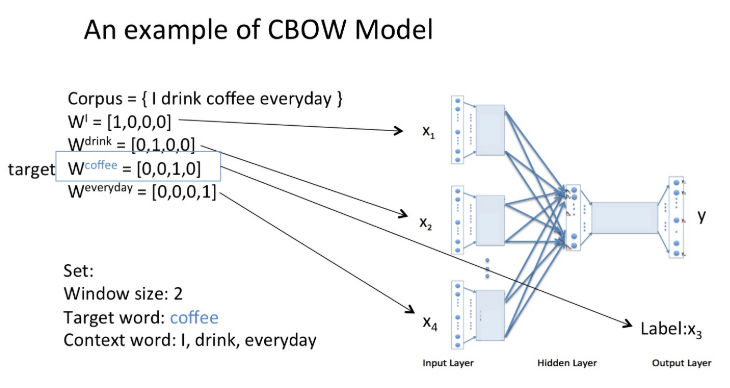  
有多少个不同的词就对应多少个不同的onehot向量  
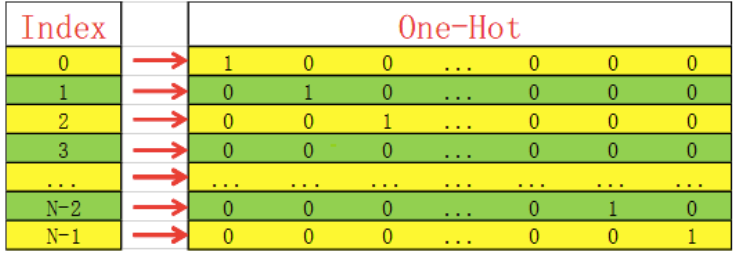  
每个词被映射成一个onehot向量

**step3：embedding**

初始化输入权重矩阵 W 和输出权重矩阵 W‘，利用这个权重矩阵W和One-hot编码完的向量相乘，可以得到唯一的向量V，相当于根据One-hot编码中1的位置取出W中的对应的列，除非两列完全相同，否则得到的向量不会是一样的。

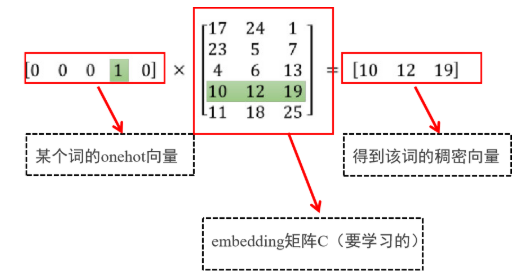  
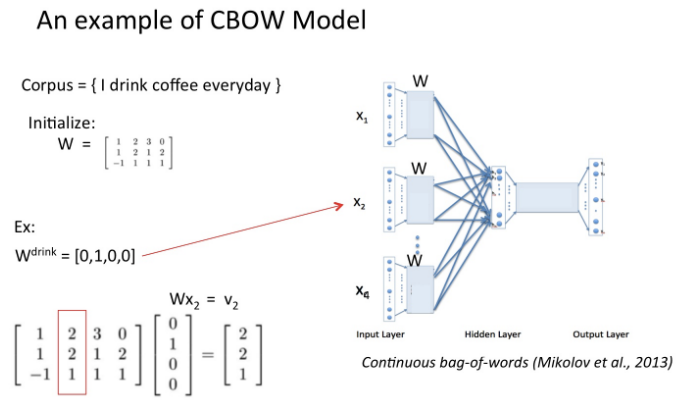  
每个onehot向量被embed成一个稠密向量（要学习的词向量）

**step4：取平均值**

我们这里有3个输入值，将3个输入值与W相乘得到的向量相加做平均，得到隐藏层向量：  
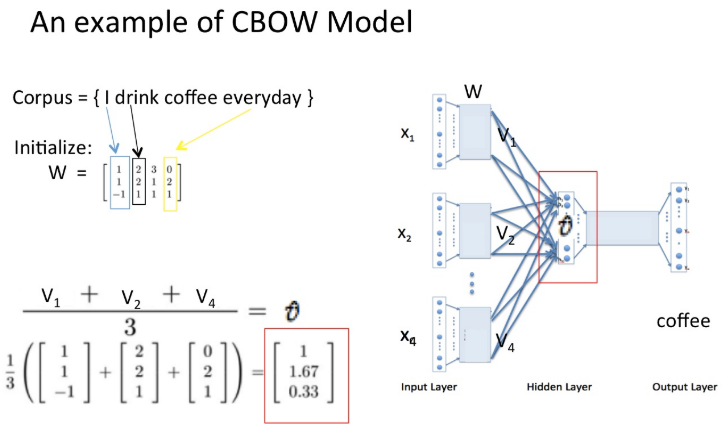  
将作为x输入的所有词的embedding向量求平均值

**step5：映射**

隐藏层向量再乘以输出权重矩阵 W‘ ，得到一个输出向量（output）：
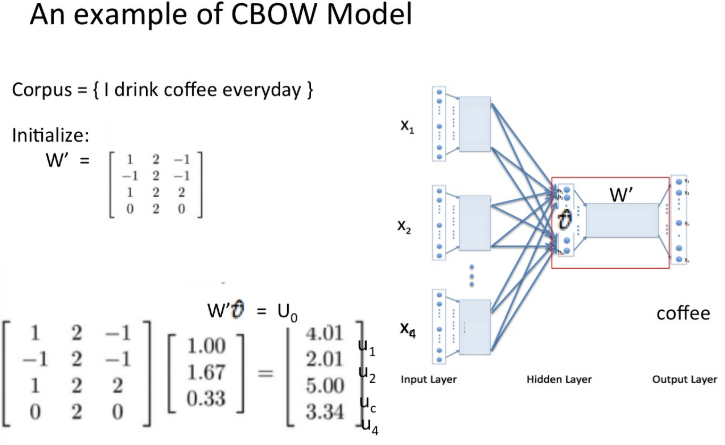  
得到平均向量后，对其进行单层神经网络映射计算,得到输出向量

**step6：输出**

对输出向量做softmax，得到输出概率：  
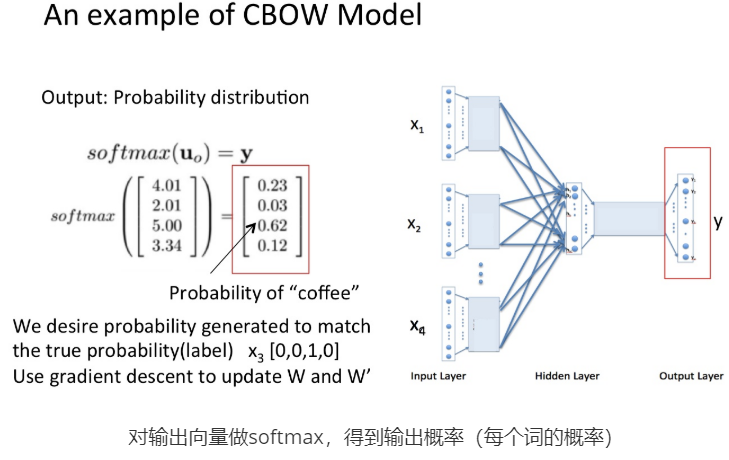  
对输出向量做softmax，得到输出概率（每个词的概率）

#### 2.3.6 Skip-Gram模型
**Skip-Gram模型思想**

Skip-Gram与CBOW相反，即已知当前词语，预测上下文。通过当前词来预测窗口中上下文词出现的概率模型，把当前词当做x，把窗口中其它词当做y，依然是通过一个隐层接一个Softmax激活函数来预测其它词的概率。

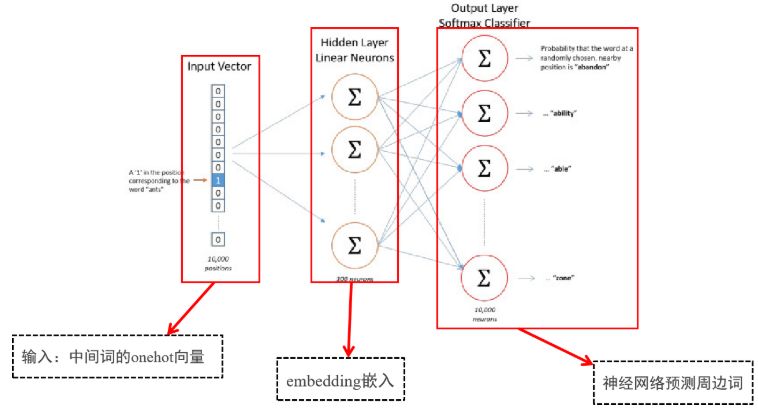

**Step1：生成训练样本**

- 以下图举例，我们选定句子“The quick brown fox jumps over lazy dog”，设定我们的窗口大小为2（window_size=2），也就是说我们将输入词前后各两个词和输入词进行组合作为训练样本。下图中，蓝色代表input word，方框内代表位于窗口内的单词。
- 以第一条为例，The为输入词，但是The开头，前面没有词跟它组合，所以只能和后面两个单词分别组合。
- 当quick输入时，它前面只有1个单词，所以一共只有3个组合。
- 从brown开始，前面才会有2个及以上的单词，所以从这里开始有4个组合。  
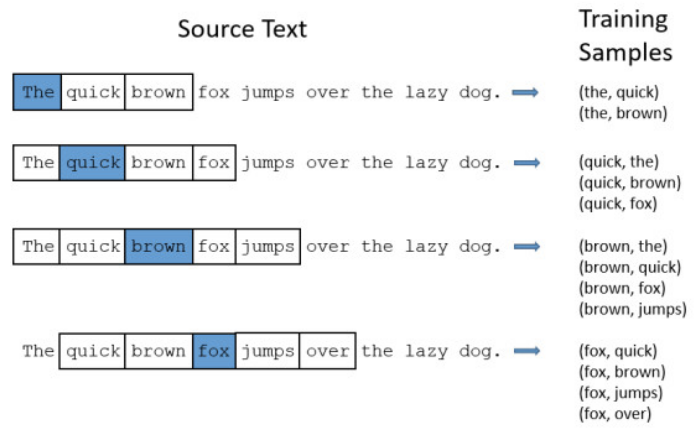  
我们的模型将会从每对单词出现的次数中习得统计结果。例如，我们的神经网络可能会得到更多类似（“Soviet“，”Union“）这样的训练样本对，而对于（”Soviet“，”Sasquatch“）这样的组合却看到的很少。因此，当我们的模型完成训练后，给定一个单词”Soviet“作为输入，输出的结果中”Union“或者”Russia“要比”Sasquatch“被赋予更高的概率。

**Step2：隐层**

如果我们现在想用300个特征来表示一个单词（即每个词可以被表示为300维的向量）。那么隐层的权重矩阵应该为10000行，300列（隐层有300个结点）。  
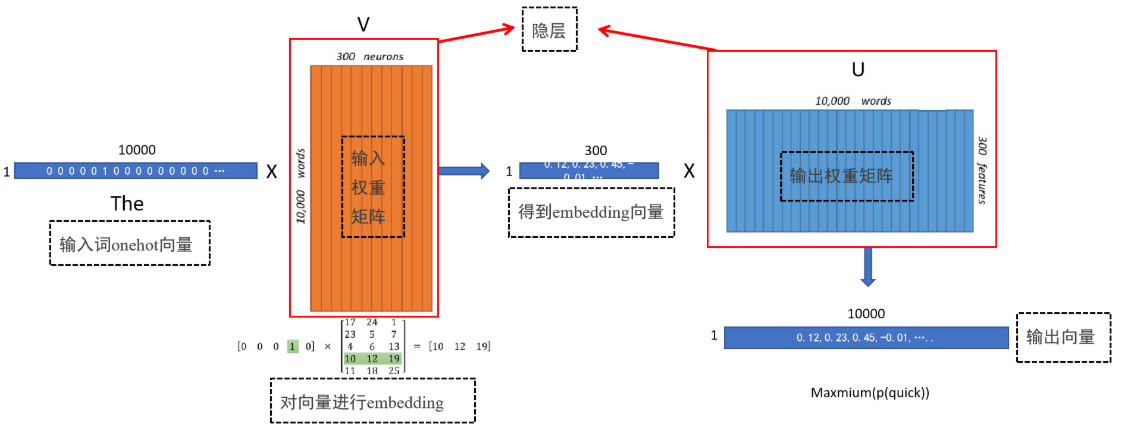

**Step3：输出层**

- 经过神经网络隐层的计算，the这个词会从一个1 x 10000的向量变成1 x 300的向量，再被输入到输出层。输出层是一个softmax回归分类器，它的每个结点将会输出一个0-1之间的值（概率），这些所有输出层神经元结点的概率(每个词的概率)之和为1。

- 下面是一个例子，训练样本为 (input word: “ants”， output word: “car”) 的计算示意图  
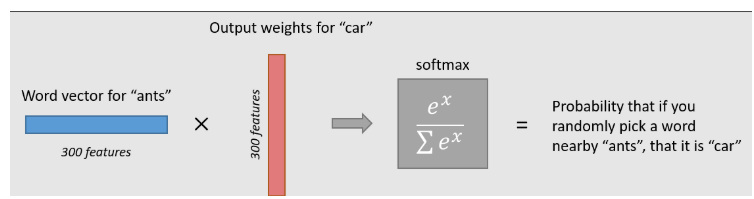  
ants的输入向量点击car的输出向量，得到car的输出值,再经过softmax得到预测car的概率

- 如果将Skip-gram模型的前向计算过程写成数学形式，我们得到：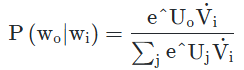

- 其中，vi是Embedding层矩阵里的列向量，也被称为wi的input vector。uj是softmax层矩阵里的行向量，也被称为wi的output vector。

- 因此，Skip-gram模型的本质是计算输入word的input vector与目标word的output vector之间的余弦相似度，并进行softmax归一化。我们要学习的模型参数正是这两类词向量。

#### 2.3.7 Word2vec训练
**训练目标**

- Skip-Gram: 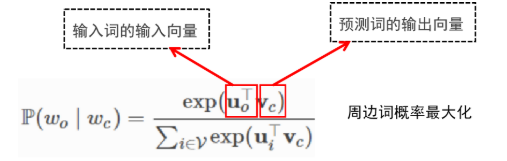
- CBOW: 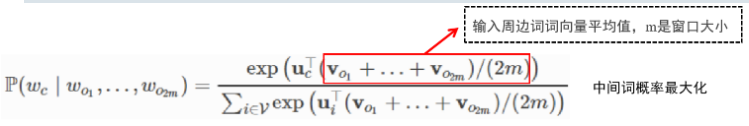

**存在的问题**

- 我们可以看到，无论是CBOW还是Skip-Gram，其模型中都有同样的两个参数矩阵V和U：  
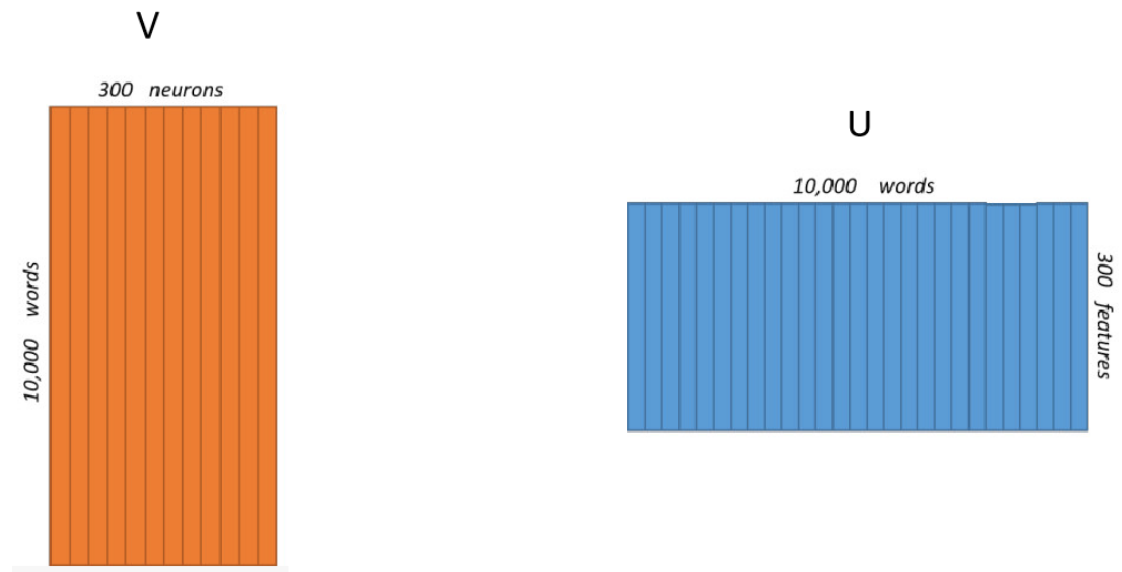  
其维度均为：词表大小*词向量长度，意味着每一次的训练都要计算这些矩阵中所有参数的梯度并进行更新。当词典较大时，例如几十万到上百万，这种训练方法的计算开销会较大 。因此，我们将使用近似的方法来计算这些梯度，从而减小计算开销。

**近似训练法**

常用的近似训练法包括:

- 层序Softmax (Hierarchical softmax)
- 负采样 (Negative Sampling)

#### 2.3.8 Hierarchical softmax
**标准softmax函数**

- softmax是一个非常标准的范畴分布，它的每个概率在0到1之间，和等于1.
- 它的损失函数也很简单，就是
$$-\sum_{i=1}^{N} \log \big( p(y_i \mid x_i; \theta) \big)$$

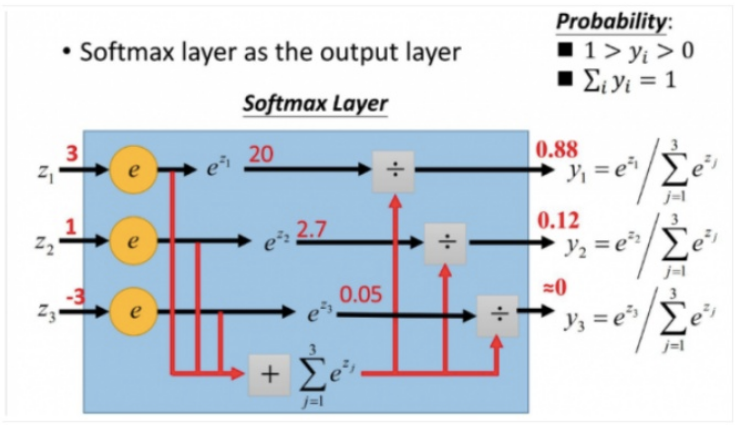

**Hierarchical softmax思想**

- Hierarchical softmax使用了Huffman编码。
- Huffman编码是为了出现频率不同的字符集设计的编码 ，而我们字典中每个单词出现的频率肯定是不同的。  
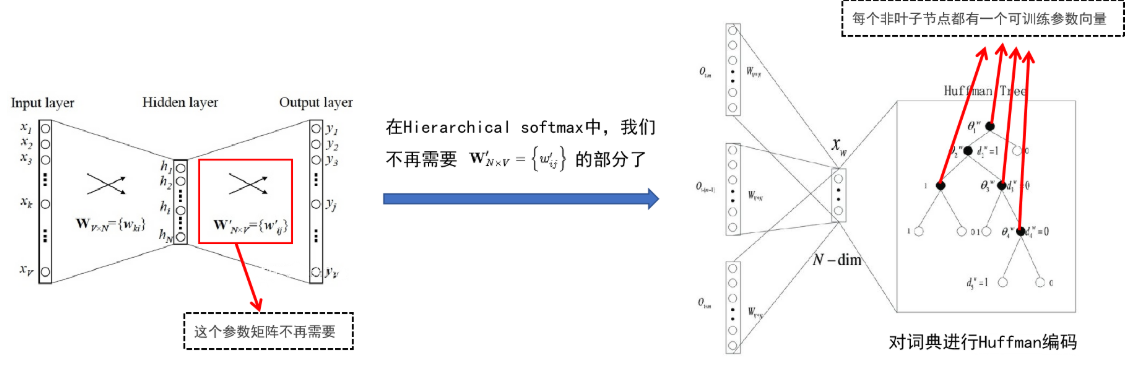

**Hierarchical softmax计算原理**

- 我们把传统的Softmax换成Hierarchical softmax，而Hierarchical softmax由一个Huffman树构成。这个Huffman树的叶子节点是所有的单词，构造规则按照词频排序。
- 层次化的Softmax的思想实质上是将一个全局多分类的问题，转化成为了若干个二元分类问题，从而将计算复杂度从O(V)降到O(logV)。  
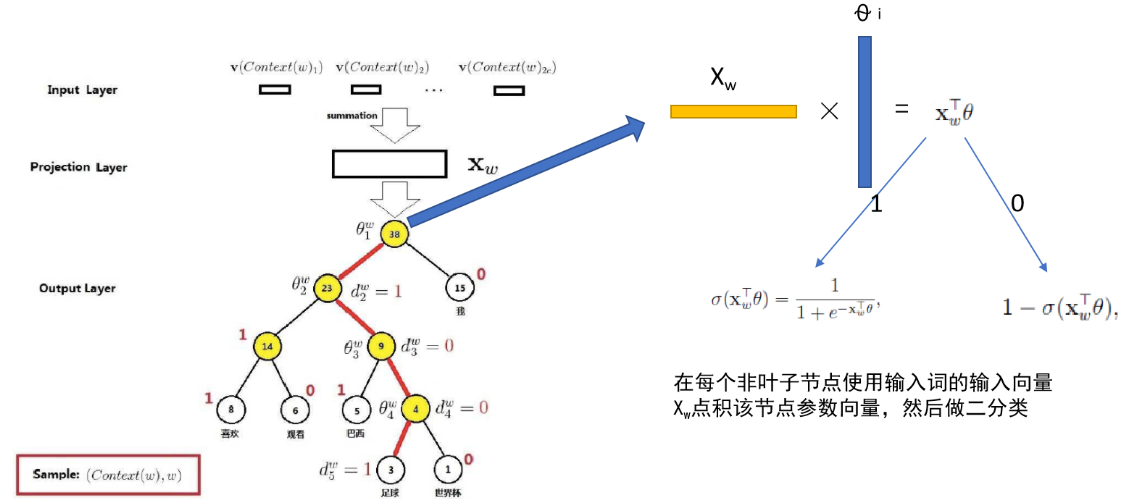

**概率计算举例**

梯度下降会改变经过的节点上的参数θ，而不会改变其他参数。而传统的Softmax则是调整了所有的参数的。  
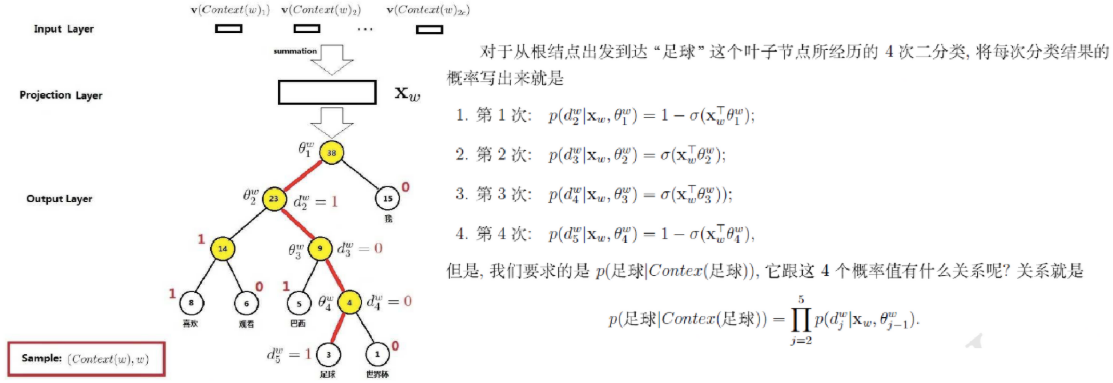

**Hierarchical softmax优势**

- 我们再说回来，Hierarchical softmax为什么更快？
- 传统的Softmax要计算下面的式子：
$$p(u = i \mid w_x) = \frac{e^{w_x^T \theta_i}}{\sum_{v=1}^{V} e^{w_x^T \theta_v}}$$
- 而当 V 很大的时候，
$$\sum_{v=1}^{V} e^{w_x^T \theta_v}$$
    的计算量是非常大的。
- 但是在Hierarchical softmax中，我们只需要计算有限个$e^{w_x^T \theta_i}$，这样就减少了计算量，因此更有优势。

#### 2.3.9 Negative Sampling
**Negative Sampling的目的**

Hierarchical softmax中通过Huffman树来帮我们在每一次训练选择出部分参数进行更新训练，是否还有其他方法也能够选择部分参数训练呢？ 我们再来看一下模型中的两个参数矩阵：

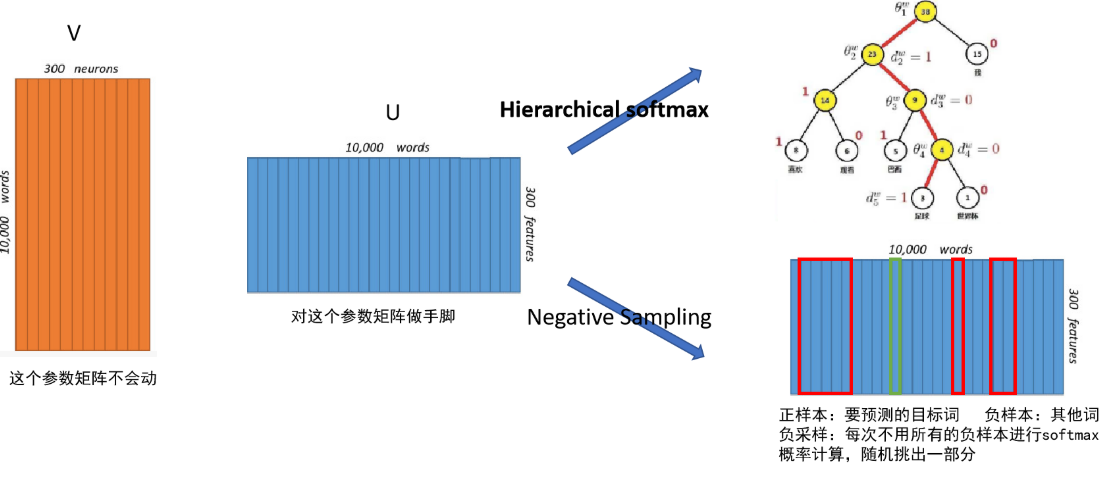

**如何采样**

在基于Negative Sampling的CBOW和Skip-gram模型中，负采样是个很重要的环节，对于一个给定的词 w , 如何生成 NEG(w) ?

- 均匀随机采样– 不可行
    - 假如给定词为“明天”，那么词表中的其他词都是负样本，但是有的词的词频高，有的词频低，并不能等同视之。
- 带权采样
    - 高频词被选为负样本的概率应该比较大，反之，低频次被选为负样本的概率应该比较小
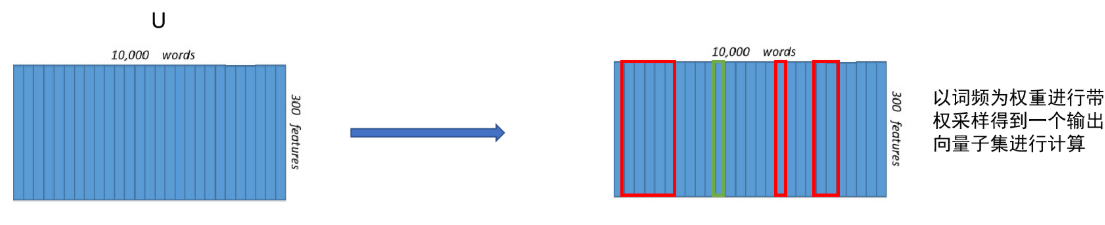

**带权采样**

词频大的词被抽中的概率大，词频小的词被抽中的概率小  
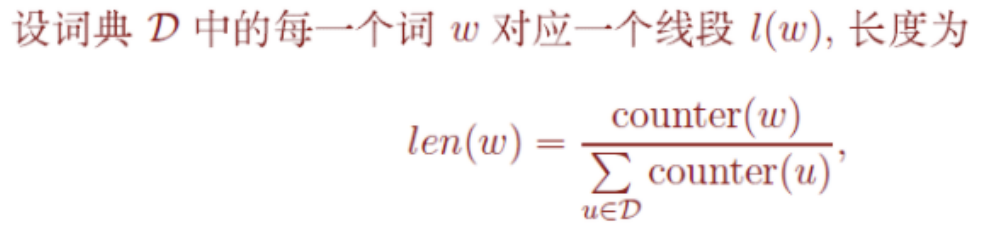  
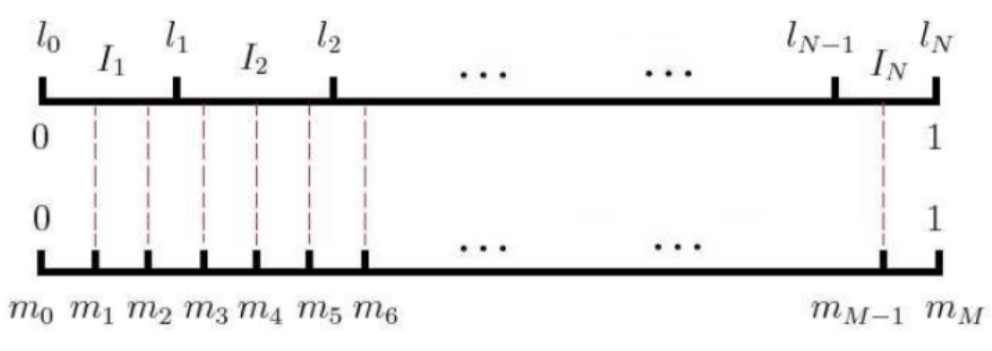  
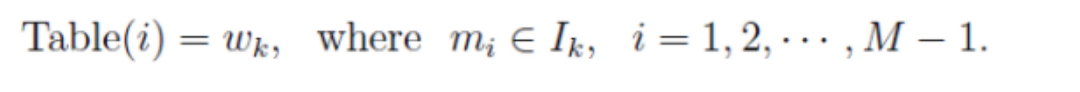

**最终实现**
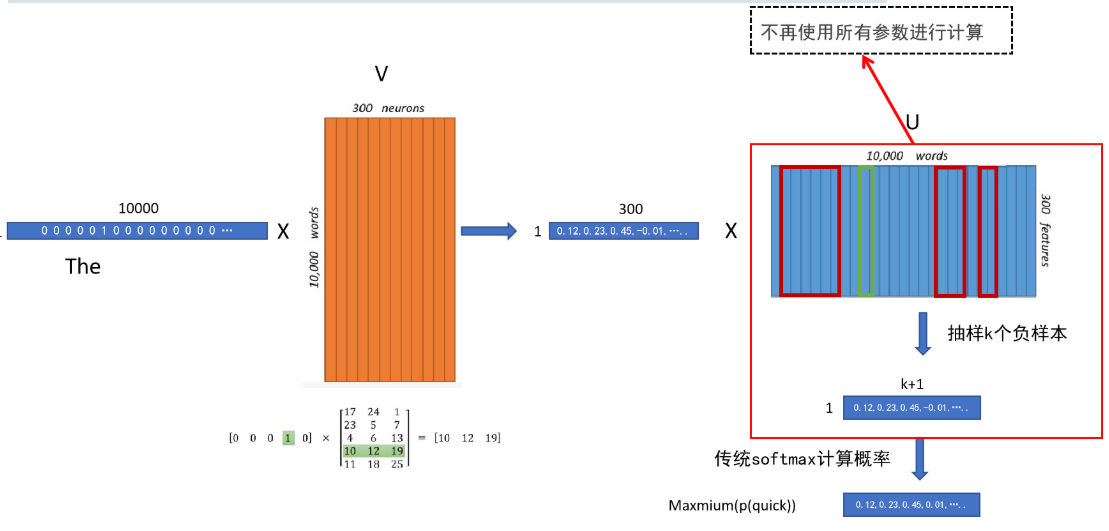

**案例-使用Gensim训练词向量**

- 结论
- 有了词向量后，我们就可以对句子进行表示，进而可以做文本分类或者相似度计算。
- 词向量也可以直接作为后续模型的输入（循环神经网络等）。

#### 2.3.10 gensim训练word2vec模型
##### 1.创建输出目录

In [1]:
# 创建输出目录
import os
output_dir = 'Dataset/word2vec/output_word2vec'

if not os.path.exists(output_dir):
    # os.mkdir(output_dir)
    os.makedirs(output_dir)

##### 2.导入数据

In [2]:
import numpy as np
import pandas as pd # 加载数据
import jieba # 分词
from gensim.models import Word2Vec # 训练
from gensim.models.word2vec import LineSentence # 封装数据
# 查看训练数据
train_data=pd.read_csv('Dataset/word2vec/sohu/sohu_train.txt',
                       sep='\t',header=None,
                       dtype=np.str_,
                       encoding='utf8',
                       names=['频道','文章'])
train_data.head()

d:\anaconda3\envs\AI_Env\lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


,频道,文章
0,娱乐,《青蛇》造型师默认新《红楼梦》额妆抄袭（图） 凡是看过电影《青蛇》的人，都不会忘记青白二蛇的...
1,娱乐,６．１６日剧榜 ＜最后的朋友＞ 亮最后杀招成功登顶 《最后的朋友》本周的电视剧排行榜单依然只...
2,娱乐,超乎想象的好看《纳尼亚传奇２：凯斯宾王子》 现时资讯如此发达，搜狐电影评审团几乎人人在没有看...
3,娱乐,吴宇森：赤壁大战不会出现在上集 “希望《赤壁》能给你们不一样的感觉。”对于自己刚刚拍完的影片...
4,娱乐,组图：《多情女人痴情男》陈浩民现场耍宝 陈浩民：外面的朋友大家好，现在是搜狐现场直播，欢迎《...


##### 3.载入停用词

In [3]:
# 载入停用词
stopwords = set()
with open('Dataset/word2vec/sohu/stopwords.txt', 'r', encoding='utf-8') as infile:
    for line in infile:
        line = line.rstrip('\n')
        if line:
            stopwords.add(line.lower())
stopwords

{'beforehand',
 '上下',
 '一来',
 'an',
 '尔',
 '因此',
 'yourselves',
 'anyway',
 '难道说',
 '宁可',
 '其二',
 'mostly',
 'nevertheless',
 '哎呀',
 'anyhow',
 '与',
 '不独',
 '︾',
 '﹡',
 '向',
 '且说',
 '正值',
 'now',
 '顺',
 '他人',
 '呗',
 '按',
 '趁',
 'next',
 'too',
 '能否',
 '管',
 '宁',
 '别管',
 'anent',
 '让',
 '有及',
 'after',
 '果然',
 '分别',
 'also',
 'vice',
 'might',
 'near',
 '嘿',
 '固然',
 '在于',
 '〞',
 '就算',
 '﹦',
 '赖以',
 '反过来',
 '›',
 '哼唷',
 '此',
 '直到',
 'these',
 '不料',
 '加以',
 '先不先',
 'behind',
 'there',
 '即',
 '若非',
 '前此',
 '为此',
 '•',
 '一切',
 'several',
 '这儿',
 '除非',
 '至若',
 '别人',
 '这般',
 '以致',
 '哈',
 'thence',
 '及其',
 '呸',
 '如其',
 '各',
 '您',
 '有关',
 '然则',
 'seem',
 '着',
 '〕',
 '一般',
 'bill',
 'many',
 '恰恰相反',
 '矣乎',
 'amid',
 '之类',
 'major',
 'whither',
 '着呢',
 'due',
 '许多',
 '尔后',
 'something',
 '不',
 'whether',
 'theirs',
 '俺',
 'in',
 '越是',
 '︰',
 'she',
 'to',
 'earlier',
 'last',
 'partly',
 '已',
 '但是',
 '小',
 '就',
 'five',
 '这么点儿',
 'seeming',
 'done',
 '；',
 '像',
 'your',
 'the',
 '甚而',
 'some',
 '

##### 4.分词

In [ ]:
article_words=[]
# 遍历每篇文章
for article in train_data[u'文章']:
    curr_words=[]
    # 遍历文章中的每个词
    for word in jieba.cut(article):
        # 去除停用词
        if word not in stopwords:
            curr_words.append(word)
    article_words.append(curr_words)
article_words[:2]

In [4]:
# 分词结果存储到文件
seg_word_file=os.path.join(output_dir,'seg_words.txt')
# with open(seg_word_file,'w',encoding='utf8') as outfile:
#     for words in article_words:
#         outfile.write(' '.join(words)+ '\n')
# print('分词结果保存到文件:{}'.format(seg_word_file))

##### 5.训练word2vec模型

In [9]:
# from gensim.test.utils import datapath
from gensim import utils
class MySentences(object):
    def __init__(self, filename):
        self.filename = filename
 
    def __iter__(self):
        #corpus_path = datapath(self.filename)
        for line in open(self.filename, encoding='utf-8', errors='ignore'):
            # assume there's one document per line, tokens separated by whitespace
            yield utils.simple_preprocess(line)

# 使用LineSentence有bug
# sentences = LineSentence(seg_word_file)

In [10]:
# 创建一个句子迭代器，一行为一个句子，词和词之间用空格分开
# 这里我们把一篇文章当作一个句子
sentences=MySentences(seg_word_file)
# 训练word2vec模型
# 参数说明：
# sentences: 包含句子的list，或迭代器
# vector_size : 词向量的维数，size越大需要越多的训练数据，同时能得到更好的模型
# alpha: 初始学习速率，随着训练过程递减，最后降到 min_alpha
# window: 上下文窗口大小，即预测当前这个词的时候最多使用距离为window大小的词
# max_vocab_size: 词表大小，如果实际词的数量超过了这个值，过滤那些频率低的
# workers: 并行度
# epochs: 训练轮数
# min_count: 忽略出现次数小于该值的词
model=Word2Vec(sentences=sentences, vector_size =100, epochs=20, min_count=1)

KeyboardInterrupt: 

In [ ]:
# 保存模型
model_file = os.path.join(output_dir, 'model.w2v')
model.save(model_file)

##### 6.word2vec模型的使用

In [11]:
# 读取模型
model_file = os.path.join(output_dir, 'model.w2v')
model2 = Word2Vec.load(model_file)

###### 6.1查找语义相近的词

In [12]:
# 封装计算相似度的函数
def invest_similar(*args, **kwargs):
    res = model2.wv.most_similar(*args, **kwargs)
    print('\n'.join([u'{}:{}'.format(x[0], x[1]) for x in res]))

In [13]:
invest_similar(u'摄影', topn = 5)

摄影师:0.5194033980369568
摄像:0.5183393955230713
影像:0.5119011998176575
摄影家:0.5114630460739136
美术:0.5112906694412231


In [14]:
# 女人 + 先生 - 男人 = 女士
# 先生 - 女士 = 男人 - 女人，这个向量的方向就代表了性别!
invest_similar(positive=['女人','先生'], negative=['男人'], topn=1)

女士:0.6139338612556458


###### 6.2 计算两个词的相似度

In [15]:
model2.wv.similarity('摄影','摄像')

np.float32(0.51833934)

###### 6.3 查询某个词的词向量

In [ ]:
model2.wv['摄影'].shape

(100,)

: 

### 2.4 基于神经网络的分布式表示-fastText
#### 2.4.1 fastText概述
**fastText概述**

- fastText是Facebook于2016年开源的一个词向量计算和文本分类工具，在文本分类任务中，fastText（浅层网络）往往能取得和深度网络相媲美的精度，却在训练时间上比深度网络快许多数量级。
- fastText是一个快速文本分类算法，与基于神经网络的分类算法相比有两大优点：
    - fastText在保持高精度的情况下加快了训练速度和测试速度
    - fastText不需要预训练好的词向量，fastText会自己训练词向量

**fastText两个重要的优化**

- Hierarchical Softmax
- N-gram

#### 2.4.2 fastText模型架构
**fastText与CBOW**

fastText模型架构和word2vec中的CBOW很相似， 不同之处是fastText预测标签而CBOW预测的是中间词，即模型架构类似但是模型的任务不同。

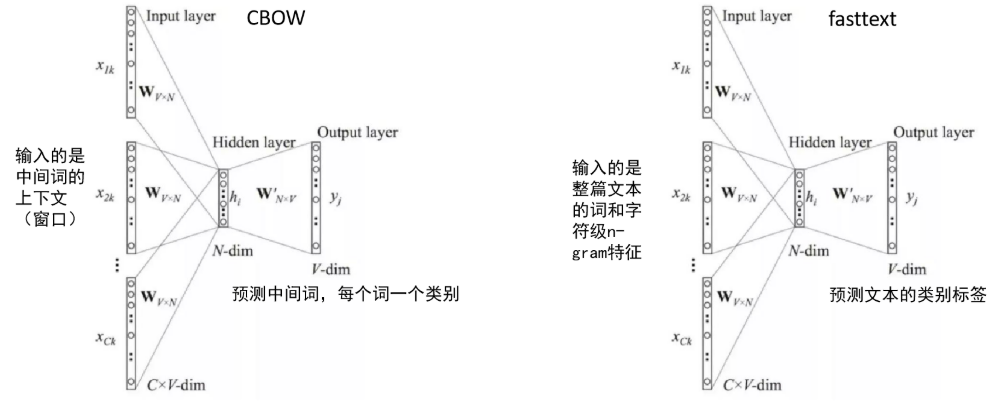

#### 2.4.3 fastText中的层次softmax
**层次softmax**

fastText模型中的层次softmax原理跟word2vec中是一样的，唯一的不同：

- word2vec中是将词看成类别，构建树使用的是词频，叶子节点代表的是词。
- fastText中是使用文本的类别标签频次构建树，叶子节点代表的是文本类别标签

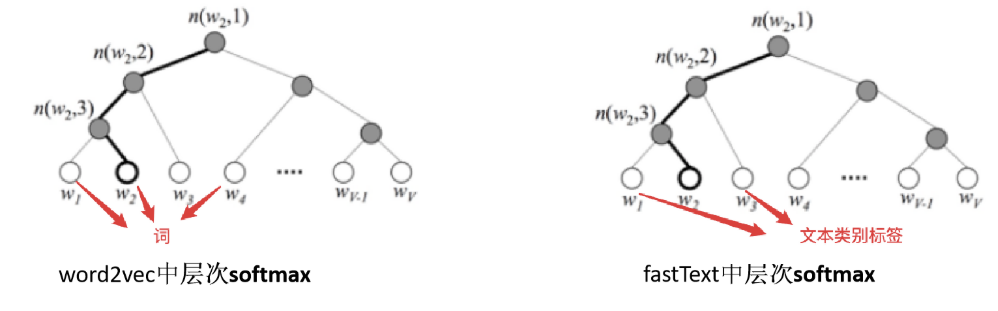

#### 2.4.4 fastText中的n-gram特征
**n-gram回顾**

- n-gram：它是一种基于语言模型的算法，基本思想是将文本内容按照字节顺序进行大小为N的滑动窗口操作，最终形成长度为N的字节片段序列。
- n-gram中的gram根据粒度分为两种
    - 字粒度
    - 词粒度

**n-gram举例**

- 字粒度
    - 我/来/到/达/分/数/据/参/观
    - 相应的bigram特征为：我来 来到 到达 达分 分数 数据 据参 参观
    - 相应的trigram特征为：我来到 来到达 到达分 达分数 分数据 数据参 据参观
- 词粒度：
    - 我/来到/达分数据/参观
    - 相应的bigram特征为：我/来到 来到/达分数据 达分数据/参观
    - 相应的trigram特征为：我/来到/达分数据 来到/达分数据/参观

**n-gram举例** n-gram也可以是字符级别的（英语等语言中）

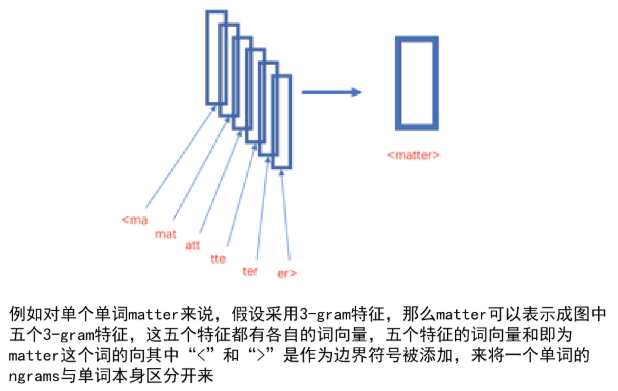

**fastText中的n-gram特征**

fastText中输入的特征有两种：

- N-gram特征
- 词特征

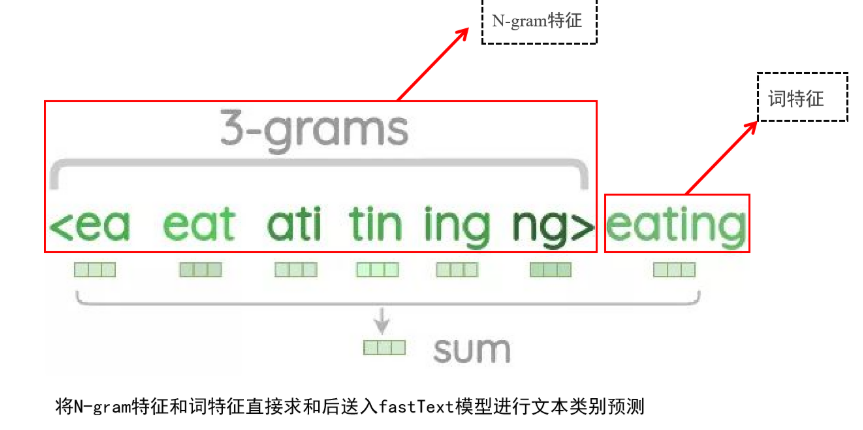

**n-gram优点**

- word2vec中词特征的缺点：
    - word2vec把语料库中的每个单词当成原子的，它会为每个单词生成一个向量。这忽略了单词内部的形态特征。
    - 比如：“apple” 和“apples”，“达分数据”和“达分”，这两个例子中，两个单词都有较多公共字符，即它们的内部形态类似，但是在传统的word2vec中，这种单词内部形态信息因为它们被转换成不同的id丢失了。
- n-gram特征带来两点好处：
    - 对于低频词生成的词向量效果会更好。因为它们的n-gram可以和其它词共享。
    - 对于训练词库之外的单词，仍然可以构建它们的词向量。我们可以叠加它们的字符级n-gram向量。

### 2.5 基于共现矩阵的词向量方法
#### 2.5.1 Glove介绍
**什么是Glove**

- Glove的全称叫Global Vectors for Word Representation，它是一个基于全局词频统计(count-based & overall statistics)的词表征 (word representation)工具。
- Glove模型是一种词向量分布表示模型，是一种无监督学习算法。总体上看，Glove模型是一种对共现矩阵（“词-词”矩阵）进行分解从而得到词表示的方法。

#### 2.5.2 共现矩阵（Co-ocurrence Matrix）
**共现矩阵相关概念**

- Co-occurrence:协同出现指的是两个单词w1和w2在一个Context Window 范围内共同出现的次数;
- Context Window:指的是某个单词w的上下文范围的大小，也就是前后多少个单词以内的才算是上下文?比如一个Context Window Size = 2 的示意图如下:

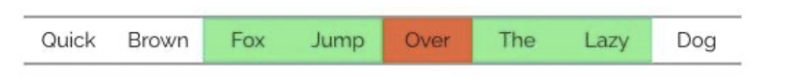

窗口为2意思是左右各2个词，表示Fox、Jump、The、Lazy跟Over共同出现一次

**共现矩阵举例**

- 比如我们有如下的语料库:
> I like deep learning.  
> I like NLP.  
> I enjoy flying.
- 我们假设Context Window=1，那么我们就可以得到如下的co-occurrence matrix:
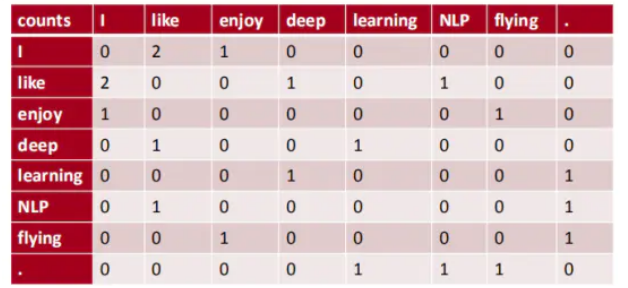  
根据语料计算得到的共线矩阵: I和like共现了2次;I和deep没有共现过.

**优点**

- 这个方法比字数统计与tf-idf都要进步一点，为什么呢? 因为它不再认为单词是独立的，而考虑了这个单词所在附近的上下文，这是一个很大 的突破。
- 如果两个单词经常出现在同一个上下文中，那么很可能他们有相同的含义。比如vodka和brandy可能经常出现在wine的上下文里， 那么在这两个单词相对于wine的co-occurrence就应该是相近的，于是 我们就可以认为这两个单词的含义是相近的。

#### 2.5.3 Glove的实现
**Glove实现分为以下三步:**

- 构建一个共现矩阵(Co-ocurrence Matrix);
- 构建词向量(Word Vector)和共现矩阵(Co-ocurrence Matrix)之间的近似关系;
- 构造loss function。

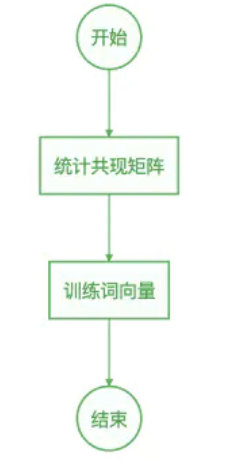

**Step1: 构建一个共现矩阵(Co-ocurrence Matrix)**

- 根据语料库(corpus)构建一个共现矩阵(Co-ocurrence Matrix)X，矩阵中的每一个元素Xij代表单词i和上下文单词j 在特定大小的上下文窗口(context window)内共同出现的次数；
- 小trick：
一般而言，次数的最小单位是1，但是GloVe不这么认为：它根据两个单词在上下文窗口的距离d提出了一个衰减函数(decreasing weighting)：decay=1/d用于计算权重，也就是说距离越远的两个单词所占总计数(total count)的权重越小。

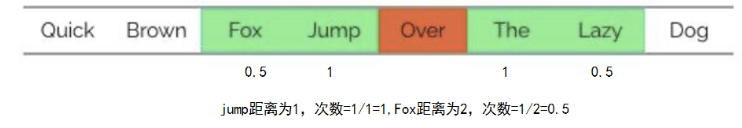

**Step2:构建词向量(Word Vector)和共现矩阵(Co-ocurrence Matrix)之间的近似关系**

- 论文的作者提出以下的公式可以近似地表达两者之间的关系: $$\large w_i^T\tilde{w}_j+b_i+\tilde{b}j=log(X{ij})$$
- 其中：$w_i^T \tilde{w}_j$是我们最终要求解的词向量；
- $b_i,\ \tilde{b}_j$是两个词向量的bias term。
- 是在共现矩阵中的第 i 行第 j 列的值

**Step3:构造损失函数**

- 有了上面的公式之后我们就可以构造它的loss function：
$$J = \sum_{i,j=1}^{V} f(X_{ij}) \left( w_i^T \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2$$
- loss function的基本形式就是最简单的mean square loss，只不过在此基础上加了一个权重函数
$$f(X_{ij})$$

**为什么要添加**
$$f(X_{ij})$$
**这个函数呢？**

- 我们知道在一个语料库中，肯定存在很多单词他们在一起出现的次数是很多的（frequent co-occurrences），那么我们希望：
- 这些单词的权重要大于那些很少在一起出现的单词（rare co-occurrences），所以这个函数要是非递减函数（non-decreasing）；
- 但我们也不希望这个权重过大（overweighted），当到达一定程度之后应该不再增加；
- 如果两个单词没有在一起出现，也就是$X_{ij} = 0$那么他们应该不参与到 loss function 的计算当中去，也就是$f(x)$要满足 f(0)=0。

满足这三个条件的函数有很多，论文作者采用了如下形式的分段函数：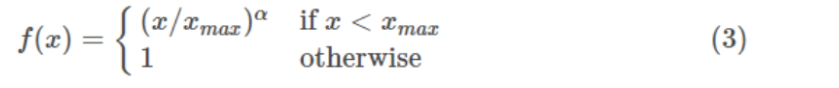

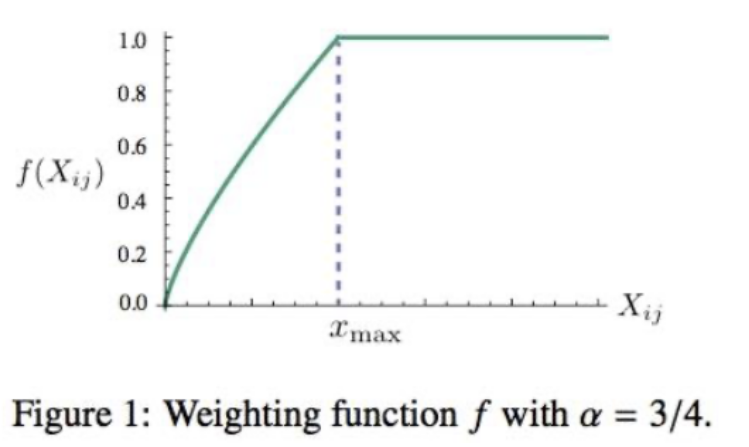

#### 2.5.4 Glove的训练
**训练方法**

- 跟word2vec一样，表面上看是无监督，实际训练是有监督，所以本质上它的训练方式跟监督学习的训练方法没什么不一样，都是基于梯度下降的。

**训练结果**

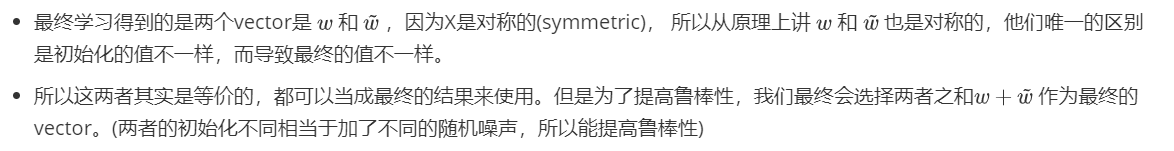

### 2.6 总结
#### 2.6.1 三种模型比较
- fasttext在word2vec基础上，加了n-gram特征，不认识的词也能组合出来。
- Glove模型相比word2vec考虑了全局信息。
- 实际工作场景中，三者的表现各有千秋，应该根据不同任务场景选择不同的表示模型。
#### 2.6.2 改进思路
- Word2vec可以和tfidf特征进行结合，利用tfidf值作为权重对词向量进行求和得到文本的特征向量。

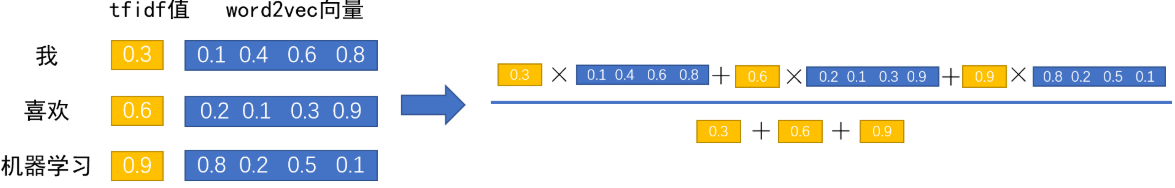

- 可以考虑将三种模型得到的向量进行拼接送入后续模型，提高泛化能力。 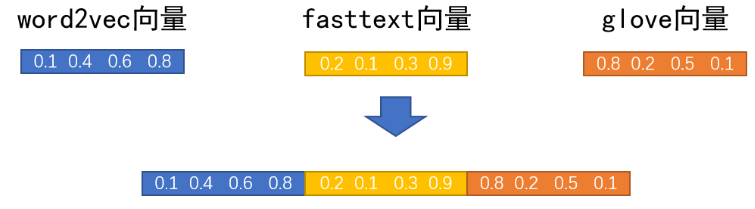

#### 2.6.3 存在的问题
- Word2vec、fasttext和glove都是对词的固定文本表示，它们都存在一个问题：词在不同的语境下其实有不同的含义，而这三个模型词在不同语境下的向量表示是相同的。
    - 今天参观了了苹果公司
    - 现在正好是苹果季节
- 针对这个问题，我们可以采用基于深度学习的动态词向量表示模型elmo、bert、gpt等，我们将在后续的章节中介绍这几个模型。